# Recs 002: Dense embeddings — per review, mean per game

## Key Goal

Generate raw-text game embeddings and retrieval artifacts (matrix/index/meta) for downstream query retrieval.

## Decision It Supports

Whether raw game embeddings are production-ready as the baseline retrieval index.

## Primary Metrics

Embedding/index integrity checks (shape, normalization, join coverage, retrieval sanity outputs).


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError(f"Could not find repo root (no pyproject.toml). cwd={here}")


REPO_ROOT = _repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "recs"
REVIEWS_LONG = ARTIFACT_DIR / "game_profile_reviews.parquet"
OUT_NPZ = ARTIFACT_DIR / "game_profile_embeddings.npz"
OUT_INDEX = ARTIFACT_DIR / "game_profile_embedding_index.parquet"
OUT_META = ARTIFACT_DIR / "game_profile_embedding_meta.json"

# English USE; 512-d embeddings. Swap URL on TF Hub if you want multilingual or another Google encoder.
TFHUB_URL = "https://tfhub.dev/google/universal-sentence-encoder/4"
BATCH_SIZE = 64
# Optional: trim very long single reviews before encode (characters). None = no trim (model truncates internally).
MAX_CHARS_PER_REVIEW: int | None = 8000

print("Reviews:", REVIEWS_LONG)
print("TF Hub:", TFHUB_URL)

Reviews: /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_reviews.parquet
TF Hub: https://tfhub.dev/google/universal-sentence-encoder/4


In [2]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf
import tensorflow_hub as hub
from tqdm.auto import tqdm

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

embed_fn = hub.load(TFHUB_URL)

2026-05-01 11:40:10.522956: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777650010.533948  111918 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777650010.537632  111918 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777650010.546924  111918 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777650010.546955  111918 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777650010.546959  111918 computation_placer.cc:177] computation placer alr

## 1) Load per-review table

In [3]:
if not REVIEWS_LONG.is_file():
    raise FileNotFoundError(f"Run recs_001 first. Missing {REVIEWS_LONG}")

df = pd.read_parquet(REVIEWS_LONG)
df = df.dropna(subset=["review"]).copy()
df["review"] = df["review"].astype(str)
df = df[df["review"].str.len() > 0]

if MAX_CHARS_PER_REVIEW is not None:
    df["_text"] = df["review"].str[:MAX_CHARS_PER_REVIEW]
else:
    df["_text"] = df["review"]

df = df.reset_index(drop=True)
print(df.shape, "rows")
print("games:", df["app_id"].nunique())

(62147, 6) rows
games: 315


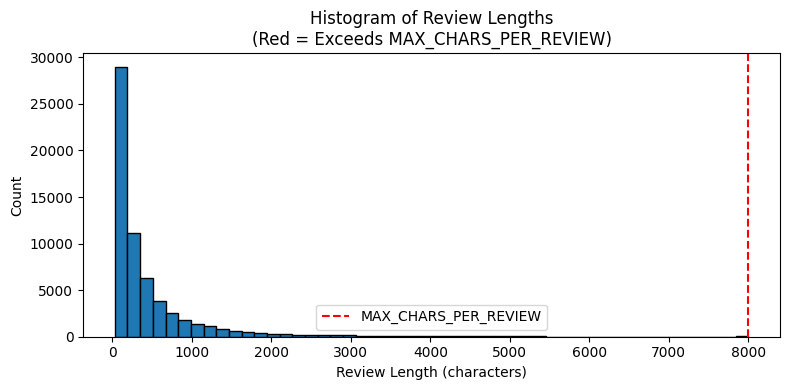

In [4]:
import matplotlib.pyplot as plt

# Compute review lengths (before truncation)
review_lens = df["review"].str.len()

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 4))
n, bins, patches = ax.hist(review_lens, bins=50, edgecolor='k')

# Color bars red if above MAX_CHARS_PER_REVIEW
if MAX_CHARS_PER_REVIEW is not None:
    for patch, bin_left in zip(patches, bins[:-1]):
        # If the right end of the bin exceeds MAX_CHARS_PER_REVIEW, color red
        if bin_left >= MAX_CHARS_PER_REVIEW:
            patch.set_facecolor('red')
        else:
            patch.set_facecolor('C0')

ax.set_xlabel("Review Length (characters)")
ax.set_ylabel("Count")
ax.set_title("Histogram of Review Lengths\n(Red = Exceeds MAX_CHARS_PER_REVIEW)")
if MAX_CHARS_PER_REVIEW is not None:
    ax.axvline(MAX_CHARS_PER_REVIEW, color='red', linestyle='--', label='MAX_CHARS_PER_REVIEW')
    ax.legend()
plt.tight_layout()
plt.show()

## 2) Encode each review, mean-pool per game, L2-normalize

In [5]:
# Convert the processed review texts to a list, to feed into the embedding function
texts = df["_text"].tolist()

# CHUNKS will hold batches of embedded review vectors
chunks: list[np.ndarray] = []

# Batch-encode all reviews for efficiency
for start in tqdm(range(0, len(texts), BATCH_SIZE), desc="encode batches"):
    batch = texts[start : start + BATCH_SIZE]              # Grab a batch from the list
    out = embed_fn(batch)                                  # Embed the batch using the preloaded embedding function
    chunks.append(np.asarray(out, dtype=np.float32))       # Convert the output to np.float32 and collect

# Concatenate all batches back into a single 2D array: (n_reviews, embedding_dim)
emb = np.concatenate(chunks, axis=0)
assert emb.ndim == 2, "emb should be 2D: (n_reviews, embedding_dim)"

# Now aggregate/mean-pool the embeddings by game (app_id).

# These lists will store the per-game outputs and associated metadata
mean_vecs: list[np.ndarray] = []
meta_app: list[int] = []
meta_name: list[str] = []

# Loop over each unique app_id (game), grouped in sorted order
for app_id, g in df.groupby("app_id", sort=True):
    idx = g.index.to_numpy()                    # Get the indices of reviews for this game
    v = emb[idx].mean(axis=0)                   # Mean-pool the review embeddings for this game
    nrm = np.linalg.norm(v)                     # Compute L2 norm

    if nrm > 1e-12:
        v = v / nrm                            # L2 normalize the mean vector (avoid division by zero)
    mean_vecs.append(v.astype(np.float32))      # Store as float32
    meta_app.append(int(app_id))                # Save game id (app_id)
    meta_name.append(str(g["app_name"].iloc[0]))# Save game name

# Build final stacked arrays for all games:
X = np.stack(mean_vecs, axis=0)                 # shape: (n_games, embedding_dim)
app_ids_arr = np.array(meta_app, dtype=np.int64) # shape: (n_games,)

print("embeddings:", X.shape)                   # Show array shape for debugging
X[0, :5]                                       # Display the first vector slice as a sample

encode batches: 100%|██████████| 972/972 [00:30<00:00, 31.79it/s]


embeddings: (315, 512)


array([-0.00272171, -0.03513855, -0.03431164,  0.01818848,  0.00673379],
      dtype=float32)

In [6]:
import random

# Examine a random embedding: pick a random game (row) and print its app_id, app_name, and embedding (first 10 dims)
idx = random.randint(0, X.shape[0] - 1)
print(f"Random game index: {idx}")
print(f"app_id: {app_ids_arr[idx]}")
print(f"app_name: {meta_name[idx]}")
print(f"embedding[:10]: {X[idx][:10]}")

Random game index: 145
app_id: 457140
app_name: Oxygen Not Included
embedding[:10]: [-0.00890502 -0.07492021 -0.00106279  0.0209751   0.01814161 -0.0042166
  0.02971666 -0.01185341  0.05714514 -0.00225366]


## 2b) What the final embeddings are (plain English)

**`X`** is the **game profile index** you will match queries against in **`recs_003`**.

| In code | In words |
|--------|----------|
| **One row = one game** | Each of the `n_games` rows is a single Steam title (identified by `app_id` / `app_name` in the same row order). |
| **512 numbers per row** | That is the output size of **Universal Sentence Encoder** — a fixed-length **semantic vector**, not readable text. |
| **Where it came from** | For that game, we embedded **each included thumbs-up review**, took the **element-wise average** of those review vectors, then **rescaled** the average to **length 1** (L2 normalize). |
| **How to interpret the digits** | Individual dimensions are **not** like “genre = column 37.” The model mixes meaning across all dimensions. What matters is **geometry**: two games with **similar** review language end up with vectors pointing in **similar directions**. |
| **Why normalize** | Unit length makes **dot product = cosine similarity** between games (and between a query and every game), which is what retrieval uses. |

The next cell prints a few **sanity numbers** (shape, norm check, one example similarity).

In [7]:
n_games, dim = X.shape
norms = np.linalg.norm(X, axis=1)

print("— Shape —")
print(f"  {n_games} games × {dim} dimensions (USE output size).")
print("— L2 norms (should be ~1.0 after normalize) —")
print(f"  min={norms.min():.6f}  max={norms.max():.6f}  mean={norms.mean():.6f}")
print("— Example —")
print(f"  Row 0: {meta_name[0]} (app_id={app_ids_arr[0]})")
print(f"  Row 1: {meta_name[1]} (app_id={app_ids_arr[1]})")
cos_01 = float(X[0] @ X[1])
print(f"  Cosine similarity (dot product) between row 0 and row 1: {cos_01:.4f}")
print("    (1 = same direction, 0 = orthogonal, negative = opposite-ish in this space.)")

— Shape —
  315 games × 512 dimensions (USE output size).
— L2 norms (should be ~1.0 after normalize) —
  min=1.000000  max=1.000000  mean=1.000000
— Example —
  Row 0: Half-Life (app_id=70)
  Row 1: Counter-Strike: Source (app_id=240)
  Cosine similarity (dot product) between row 0 and row 1: 0.8809
    (1 = same direction, 0 = orthogonal, negative = opposite-ish in this space.)


## 3) Review embeddings for a list of games

After **`X`** is built, inspect **L2-normalized** vectors for games you care about. Edit **`REVIEW_APP_IDS`** (and optionally **`REVIEW_NAME_CONTAINS`**) below (or use **`SHOW_ALL_GAMES`**).

- **`l2_norm`** should be **~1.0** (numerical float error is normal).
- **Pairwise table** is **cosine similarity** (same as dot product here).

,app_id,app_name,l2_norm,dim,first_8_dims
0,70,Half-Life,1.0,512,[-0.0027 -0.0351 -0.0343 0.0182 0.0067 -0.02...
1,420,Half-Life 2: Episode Two,1.0,512,[ 0.018 -0.0523 -0.0183 0.0163 0.0293 -0.06...
2,620,Portal 2,1.0,512,[ 0.0069 -0.0478 -0.0295 0.009 0.017 -0.01...
3,8930,Sid Meier's Civilization V,1.0,512,[ 0.0162 -0.0957 -0.0264 -0.0034 0.0169 0.03...
4,72850,The Elder Scrolls V: Skyrim,1.0,512,[-0.003 -0.0539 0.0032 0.0083 0.0246 0.04...
5,105600,Terraria,1.0,512,[ 0.0103 -0.0684 -0.0179 -0.0025 0.0039 0.01...
6,289070,Sid Meier's Civilization VI,1.0,512,[-0.0031 -0.0995 -0.0105 -0.0128 0.0159 0.04...
7,292030,The Witcher 3: Wild Hunt,1.0,512,[-0.0179 -0.0622 -0.0111 0.0332 0.0041 0.00...
8,306130,The Elder Scrolls Online,1.0,512,[-0.0199 -0.0717 0.0267 0.0177 0.0413 0.05...
9,413150,Stardew Valley,1.0,512,[ 0.0153 -0.0618 -0.0152 0.0288 -0.0241 0.02...


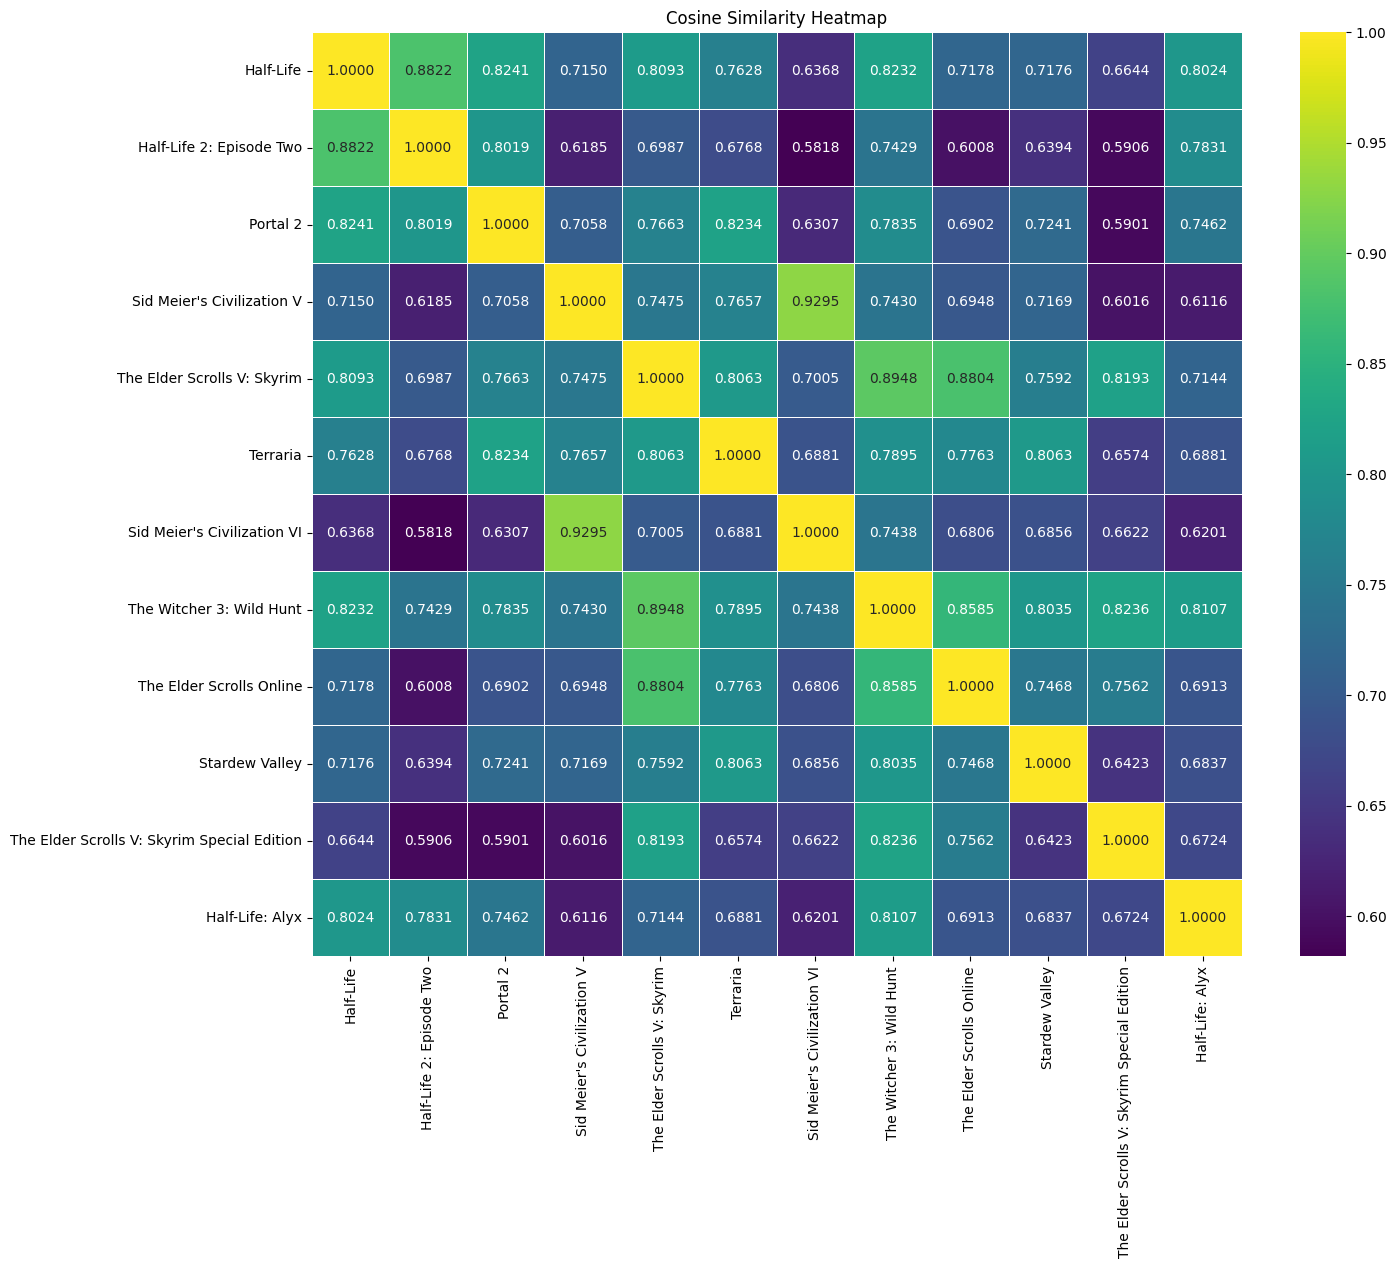

In [8]:
# Pick games by app_id (primary) and/or name substring (extra rows).
# To show all game names, set SHOW_ALL_GAMES = True.
SHOW_ALL_GAMES = False  # Set to True to just see the whole list
REVIEW_APP_IDS: list[int] = [
    # 70,  # Half-Life — replace / extend with app_ids from your index
]
REVIEW_NAME_CONTAINS: list[str] = [
    "Portal",
    "Half-Life",
    "Civilization",
    "Stardew Valley",
    "Terraria",
    "Minecraft",
    "The Witcher",
    "The Elder Scrolls",
]

_index_tbl = pd.DataFrame({"app_id": meta_app, "app_name": meta_name})
_row_by_app = {int(a): i for i, a in enumerate(meta_app)}

if SHOW_ALL_GAMES:
    display(_index_tbl)
else:
    picked_rows: list[int] = []
    for a in REVIEW_APP_IDS:
        if a in _row_by_app:
            picked_rows.append(_row_by_app[a])
        else:
            print(f"[missing app_id] {a}")
    for sub in REVIEW_NAME_CONTAINS:
        if not sub:
            continue
        m = _index_tbl[_index_tbl["app_name"].str.contains(sub, case=False, regex=False, na=False)]
        for _, r in m.iterrows():
            picked_rows.append(_row_by_app[int(r["app_id"])])

    picked_rows = sorted(set(picked_rows))
    if not picked_rows:
        print("No games matched. Set REVIEW_APP_IDS or REVIEW_NAME_CONTAINS, or set SHOW_ALL_GAMES = True to see everything.")
    else:
        sel = np.array(picked_rows, dtype=np.int64)
        V = X[sel]
        names = [_index_tbl["app_name"].iloc[i] for i in picked_rows]
        app_ids = [_index_tbl["app_id"].iloc[i] for i in picked_rows]

        review_df = pd.DataFrame(
            {
                "app_id": app_ids,
                "app_name": names,
                "l2_norm": np.linalg.norm(V, axis=1),
                "dim": V.shape[1],
                "first_8_dims": [np.array2string(V[j, :8], precision=4, suppress_small=True) for j in range(len(sel))],
            }
        )
        display(review_df)

        if len(sel) >= 2:
            import matplotlib.pyplot as plt
            import seaborn as sns

            sim = V @ V.T
            sim_df = pd.DataFrame(sim, index=names, columns=names).round(4)
            plt.figure(figsize=(len(names) * 1.25, len(names)))
            sns.heatmap(sim_df, annot=True, fmt=".4f", cmap="viridis", linewidths=0.5)
            plt.title("Cosine Similarity Heatmap")
            plt.yticks(rotation=0)
            plt.show()

## 4) Confirm Artifacts

In [9]:
# QA-only: validate existing artifacts generated by pipeline job.
for path in [OUT_NPZ, OUT_INDEX, OUT_META]:
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing {path}. Run scripts/recs_job_game_embeddings.py first."
        )

with np.load(OUT_NPZ) as z:
    X_art = np.asarray(z["embeddings"], dtype=np.float32)
    app_ids_art = np.asarray(z["app_id"], dtype=np.int64)

index_art = pd.read_parquet(OUT_INDEX)
meta_art = json.loads(OUT_META.read_text(encoding="utf-8"))

print("Validated existing artifacts:")
print(" ", OUT_NPZ)
print(" ", OUT_INDEX)
print(" ", OUT_META)
print("artifact embeddings:", X_art.shape, "computed embeddings:", X.shape)
print("artifact app_id rows:", len(app_ids_art), "computed app_id rows:", len(app_ids_arr))
print("artifact index rows:", len(index_art), "computed meta rows:", len(meta_app))
print("artifact meta n_games:", meta_art.get("n_games"), "computed n_games:", int(X.shape[0]))
print("artifact meta dim:", meta_art.get("dim"), "computed dim:", int(X.shape[1]))

Validated existing artifacts:
  /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_embeddings.npz
  /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_embedding_index.parquet
  /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_embedding_meta.json
artifact embeddings: (315, 512) computed embeddings: (315, 512)
artifact app_id rows: 315 computed app_id rows: 315
artifact index rows: 315 computed meta rows: 315
artifact meta n_games: 315 computed n_games: 315
artifact meta dim: 512 computed dim: 512


## Standard QA gate

Standardized artifact QA checks (aligned with `recs_005`):

- shape/alignment checks
- app-id uniqueness and set parity
- embedding norm sanity (L2)
- metadata completeness
- compact fingerprint output

In [10]:
required_meta_keys = {
    "model_name",
    "backend",
    "method",
    "text_mode",
    "max_chars_per_review",
    "n_games",
    "dim",
    "n_review_rows_encoded",
}

checks = []

# Alignment and shape checks
checks.append(("matrix_is_2d", bool(X_art.ndim == 2), f"shape={X_art.shape}"))
checks.append(("npz_app_id_len_matches_rows", bool(len(app_ids_art) == X_art.shape[0]), f"app_ids={len(app_ids_art)} rows={X_art.shape[0]}"))
checks.append(("index_rows_match_rows", bool(len(index_art) == X_art.shape[0]), f"index_rows={len(index_art)} rows={X_art.shape[0]}"))

# Uniqueness + order + set parity
idx_app = index_art["app_id"].to_numpy(dtype=np.int64)
checks.append(("index_app_id_unique", bool(pd.Series(idx_app).is_unique), f"unique={pd.Series(idx_app).is_unique}"))
checks.append(("npz_index_order_match", bool(np.array_equal(idx_app, app_ids_art)), "order_equal"))
checks.append(("id_set_parity_vs_reviews", bool(set(idx_app.tolist()) == set(df["app_id"].astype(int).unique().tolist())), f"idx={len(set(idx_app.tolist()))} reviews={df['app_id'].nunique()}"))

# Norm sanity
norms = np.linalg.norm(X_art, axis=1)
checks.append(("norms_finite", bool(np.isfinite(norms).all()), "all finite"))
checks.append(("norms_near_one", bool(np.allclose(norms, 1.0, atol=1e-3)), f"min={norms.min():.6f} mean={norms.mean():.6f} max={norms.max():.6f}"))

# Metadata sanity
meta_keys_ok = required_meta_keys.issubset(set(meta_art.keys()))
checks.append(("meta_required_keys_present", bool(meta_keys_ok), f"missing={sorted(required_meta_keys.difference(set(meta_art.keys())))}"))
checks.append(("meta_n_games_match", bool(int(meta_art.get("n_games", -1)) == int(X_art.shape[0])), f"meta={meta_art.get('n_games')} rows={X_art.shape[0]}"))
checks.append(("meta_dim_match", bool(int(meta_art.get("dim", -1)) == int(X_art.shape[1])), f"meta={meta_art.get('dim')} dim={X_art.shape[1]}"))
checks.append(("meta_text_mode_raw", bool(meta_art.get("text_mode") == "raw"), f"text_mode={meta_art.get('text_mode')}"))

qa_df = pd.DataFrame(checks, columns=["check", "pass", "detail"])
display(qa_df)

if not qa_df["pass"].all():
    failed = qa_df.loc[~qa_df["pass"], ["check", "detail"]]
    raise RuntimeError("Raw artifact QA gate failed:\n" + failed.to_string(index=False))

print("Raw QA gate passed.")
print("Fingerprint app_ids[:5]:", app_ids_art[:5].tolist())
print("Fingerprint vec[0,:5]:", X_art[0, :5].tolist())

,check,pass,detail
0,matrix_is_2d,True,"shape=(315, 512)"
1,npz_app_id_len_matches_rows,True,app_ids=315 rows=315
2,index_rows_match_rows,True,index_rows=315 rows=315
3,index_app_id_unique,True,unique=True
4,npz_index_order_match,True,order_equal
5,id_set_parity_vs_reviews,True,idx=315 reviews=315
6,norms_finite,True,all finite
7,norms_near_one,True,min=1.000000 mean=1.000000 max=1.000000
8,meta_required_keys_present,True,missing=[]
9,meta_n_games_match,True,meta=315 rows=315


Raw QA gate passed.
Fingerprint app_ids[:5]: [70, 240, 420, 620, 2870]
Fingerprint vec[0,:5]: [-0.0027217785827815533, -0.035138435661792755, -0.034311648458242416, 0.018188511952757835, 0.006733761169016361]
